### 🧩 Pairwise Distance Matrix

> A valid distance matrix has specific structure that follows from the metric axioms: the diagonal is zero (identity), the matrix is symmetric, and all entries are non-negative. Think about how to exploit symmetry to avoid redundant computation.

Build a 20x20 matrix where entry (i, j) is the distance between sample i and sample j.

The samples are ordered by variety (S01–S05 cold brew, S06–S10 drip, S11–S15 espresso, S16–S20 latte), so clusters should appear as **dark blocks along the diagonal**.

### 🗺️ Distance Heatmaps

> The lecture argues that the metric is a modelling choice that encodes your assumptions. When comparing the three heatmaps, pay attention to which pairs of varieties each metric considers similar. Where do they disagree, and can you explain why from the properties of each metric?

We plot heatmaps for Euclidean, Manhattan, and Cosine distances side by side.
Dark = close, bright = far apart. Look for block structure along the diagonal.

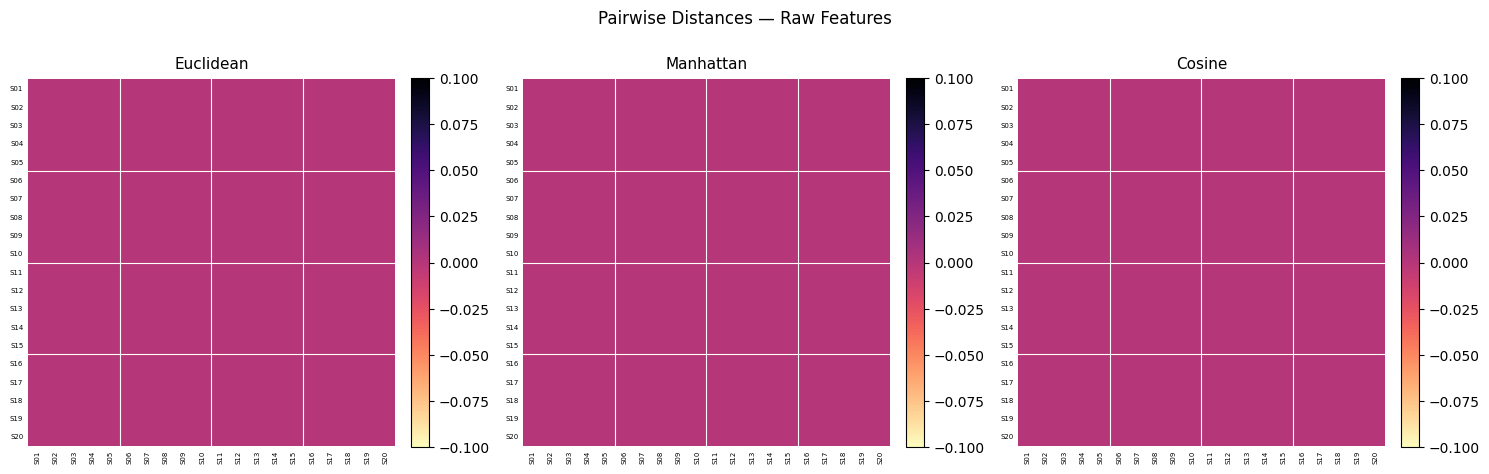

In [ ]:
# Compute distance matrices for all three metrics
D_euclid = pairwise_distance_matrix(features, euclidean_distance)
D_manhat = pairwise_distance_matrix(features, manhattan_distance)
D_cosine = pairwise_distance_matrix(features, cosine_distance)


def plot_heatmaps(matrices, titles, sample_ids, labels, suptitle=''):
    """Plot distance matrices as heatmaps with variety separators."""
    n_plots = len(matrices)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4.5))
    if n_plots == 1:
        axes = [axes]

    for ax, D, title in zip(axes, matrices, titles):
        im = ax.imshow(D, cmap='magma_r', aspect='equal')
        ax.set_title(title, fontsize=11, pad=8)
        ax.set_xticks(range(len(sample_ids)))
        ax.set_yticks(range(len(sample_ids)))
        ax.set_xticklabels(sample_ids, rotation=90, fontsize=5)
        ax.set_yticklabels(sample_ids, fontsize=5)

        # Variety boundary lines
        for boundary in [5, 10, 15]:
            ax.axhline(boundary - 0.5, color='white', linewidth=0.8)
            ax.axvline(boundary - 0.5, color='white', linewidth=0.8)

        ax.tick_params(axis='both', which='both', length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


plot_heatmaps(
    [D_euclid, D_manhat, D_cosine],
    ['Euclidean', 'Manhattan', 'Cosine'],
    sample_ids, labels,
    suptitle='Pairwise Distances — Raw Features'
)

In [ ]:
def pairwise_distance_matrix(data, dist_func):
    """Compute an NxN distance matrix using the given distance function."""
    n = len(data)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            # YOUR CODE HERE
            # Compute distance between data[i] and data[j]
            # Fill in both D[i, j] and D[j, i] (symmetry!)
            pass
    return D


D_euclid = pairwise_distance_matrix(features, euclidean_distance)
check_pairwise(D_euclid, features, euclidean_distance)

  ❌ Distance matrix is all zeros.
       Expected d(S01, S02) = N/A (dist_func returned None)
       Hint: make sure you assign the computed distance to D[i, j]
       and D[j, i] inside the loop.


**Observe the raw-feature heatmaps:**
- Euclidean and Manhattan are dominated by **brew strength** (range 5–25) because it has the largest scale. Acidity (4–7) and bitterness (1–10) barely contribute.
- Cold brew and espresso both have high brew strength, so they appear **close to each other** despite having very different acidity and bitterness profiles.
- The four variety blocks are **not** cleanly visible — the scale mismatch hides the true cluster structure.
- Cosine similarity tells a different story: it ignores magnitude and compares the *direction* of the feature vectors.

### 🔥 Before vs. After — Heatmap Comparison

> You saw that Mahalanobis distance uses the covariance to rescale space, and z-score normalization also rescales each dimension by its standard deviation. Are these two approaches solving the same problem? If you apply Euclidean distance after z-score normalization, do you get the same result as Mahalanobis on the raw data?

<details><summary>Thought</summary>

They overlap but are not identical. Z-score normalization corrects for different variances per feature (the diagonal of the covariance), so Euclidean-after-z-score handles scale differences. Mahalanobis additionally accounts for correlations between features (the off-diagonal entries). If features are uncorrelated, the two approaches give the same result. If features are correlated, Mahalanobis still captures structure that z-score + Euclidean misses.
</details>

Recompute the Euclidean distance matrices on the normalized features and compare the heatmaps side by side. Watch how the cluster blocks emerge.

In [ ]:
# Distance matrices on normalized features
D_raw = pairwise_distance_matrix(features, euclidean_distance)
D_zscore = pairwise_distance_matrix(features_z, euclidean_distance)
D_minmax = pairwise_distance_matrix(features_mm, euclidean_distance)

plot_heatmaps(
    [D_raw, D_zscore, D_minmax],
    ["Raw Features", "Z-Score Normalized", "Min-Max Scaled"],
    sample_ids, labels,
    suptitle="Euclidean Distance — Effect of Normalization"
)


TypeError: object of type 'NoneType' has no len()

**Observe:**
- After normalization, **four dark blocks** appear along the diagonal — one per variety. The cluster structure is now clearly visible.
- Cold brew and espresso are no longer confused: their high brew strength was the only thing making them look similar on raw features.
- The latte sample S19 (brew strength 21) may still appear as an outlier — check whether it stands out in the heatmap.
